# `wide_to_long` do Pandas


Professor [Francisco Bustamante](https://linkedin.com/in/flsbustamante)

O método `wide_to_long` do pandas é utilizado para transformar um DataFrame de formato largo para um formato longo, especialmente quando os nomes das colunas seguem um padrão consistente. Este método é particularmente útil quando as colunas do DataFrame possuem um prefixo comum e diferentes sufixos que indicam variáveis específicas ou períodos de tempo.

O método `wide_to_long` reorganiza os dados de modo que várias colunas de uma variável são combinadas em uma única coluna. Ele converte um DataFrame de formato largo, onde cada coluna representa uma variável separada, em um DataFrame de formato longo, onde cada linha representa uma observação de uma variável específica.

Use o `wide_to_long` quando:

1. **Colunas com padrões consistentes**: Os nomes das colunas seguem um padrão consistente, como um prefixo comum com diferentes sufixos que identificam variáveis ou períodos de tempo. Por exemplo, colunas como `vendas_T1`, `vendas_T2`, `despesas_T1`, `despesas_T2`.

2. **Reorganizar variáveis repetidas**: Você precisa transformar variáveis que se repetem em colunas distintas para uma única coluna com todas as observações, facilitando análises e visualizações.

3. **Facilitar análises temporais**: Quando os dados são coletados ao longo de diferentes períodos e você deseja reorganizá-los para realizar análises temporais ou comparações entre diferentes categorias.


Contexto: 

Uma empresa que gerencia informações financeiras de diferentes produtos ao longo do ano. Os dados de vendas e despesas são coletados trimestralmente e estão organizados em uma base de dados em formato largo, onde cada coluna representa um trimestre específico.

O objetivo é reorganizar os dados para facilitar análises temporais e cálculos adicionais.

In [1]:
import pandas as pd

BASE = "./dados/vendas_produtos_trimestres.csv"

dados = pd.read_csv(BASE)

dados

,produto_id,produto_nome,vendas_T1,vendas_T2,vendas_T3,vendas_T4,despesas_T1,despesas_T2,despesas_T3,despesas_T4
0,1,Produto A,14499,24847,18720,26298,17779,8576,8978,14173
1,2,Produto B,16672,15275,12837,23786,11650,14201,18199,13572
2,3,Produto C,19332,29591,19245,16148,9435,14055,14165,17485
3,4,Produto D,24457,19382,12464,26894,15352,9769,12313,18657
4,5,Produto E,18822,23977,26087,26793,19512,12423,9400,19583


In [2]:
# Usando wide_to_long para transformar o DataFrame
dados_long = pd.wide_to_long(
    dados,
    stubnames=["vendas", "despesas"],
    i=["produto_id", "produto_nome"],
    j="trimestre",
    sep="_",
    suffix=r"\w+",  # w+ significa que vai pegar qualquer caractere alfanumérico
).reset_index()

dados_long

,produto_id,produto_nome,trimestre,vendas,despesas
0,1,Produto A,T1,14499,17779
1,1,Produto A,T2,24847,8576
2,1,Produto A,T3,18720,8978
3,1,Produto A,T4,26298,14173
4,2,Produto B,T1,16672,11650
5,2,Produto B,T2,15275,14201
6,2,Produto B,T3,12837,18199
7,2,Produto B,T4,23786,13572
8,3,Produto C,T1,19332,9435
9,3,Produto C,T2,29591,14055


Vídeo com mais detalhes sobre regex (e cita mais referências a respeito): https://www.youtube.com/watch?v=sQWpUE1HH2Q

In [3]:
# calculando o lucro
dados_long["lucro"] = dados_long["vendas"] - dados_long["despesas"]

dados_long

,produto_id,produto_nome,trimestre,vendas,despesas,lucro
0,1,Produto A,T1,14499,17779,-3280
1,1,Produto A,T2,24847,8576,16271
2,1,Produto A,T3,18720,8978,9742
3,1,Produto A,T4,26298,14173,12125
4,2,Produto B,T1,16672,11650,5022
5,2,Produto B,T2,15275,14201,1074
6,2,Produto B,T3,12837,18199,-5362
7,2,Produto B,T4,23786,13572,10214
8,3,Produto C,T1,19332,9435,9897
9,3,Produto C,T2,29591,14055,15536


In [4]:
dados_long.groupby("produto_nome")[["vendas", "despesas", "lucro"]].sum()

,vendas,despesas,lucro
produto_nome,,,
Produto A,84364,49506,34858
Produto B,68570,57622,10948
Produto C,84316,55140,29176
Produto D,83197,56091,27106
Produto E,95679,60918,34761


In [5]:
# média de vendas, despesas e lucro por trimestre
dados_long.groupby("trimestre")[["vendas", "despesas", "lucro"]].mean()

,vendas,despesas,lucro
trimestre,,,
T1,18756.4,14745.6,4010.8
T2,22614.4,11804.8,10809.6
T3,17870.6,12611.0,5259.6
T4,23983.8,16694.0,7289.8


In [6]:
# média de vendas, despesas e lucro por produto
dados_long.groupby("produto_nome")[["vendas", "despesas", "lucro"]].mean()

,vendas,despesas,lucro
produto_nome,,,
Produto A,21091.00,12376.50,8714.50
Produto B,17142.50,14405.50,2737.00
Produto C,21079.00,13785.00,7294.00
Produto D,20799.25,14022.75,6776.50
Produto E,23919.75,15229.50,8690.25


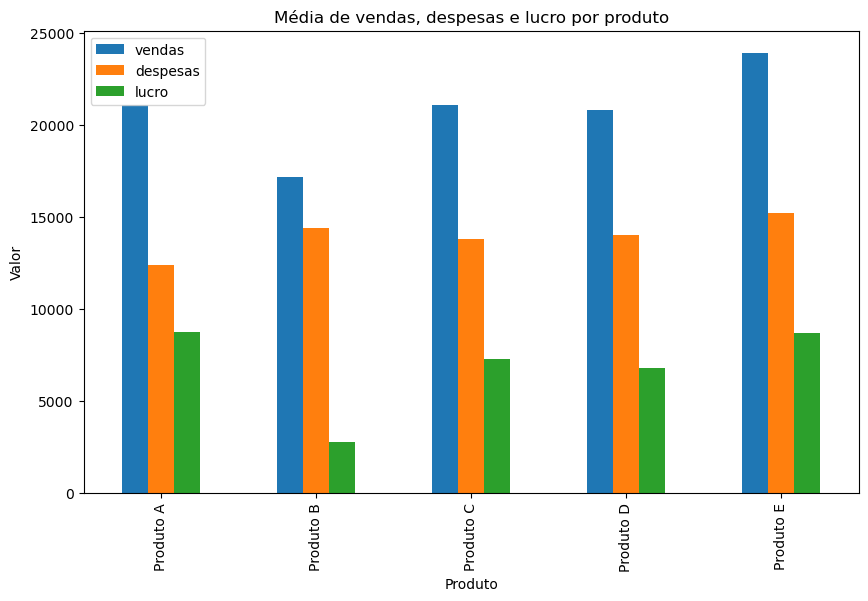

In [7]:
# gráfico de barras
import matplotlib.pyplot as plt

dados_long.groupby("produto_nome")[["vendas", "despesas", "lucro"]].mean().plot(
    kind="bar", figsize=(10, 6)
)

plt.title("Média de vendas, despesas e lucro por produto")
plt.xlabel("Produto")
plt.ylabel("Valor")

plt.show()

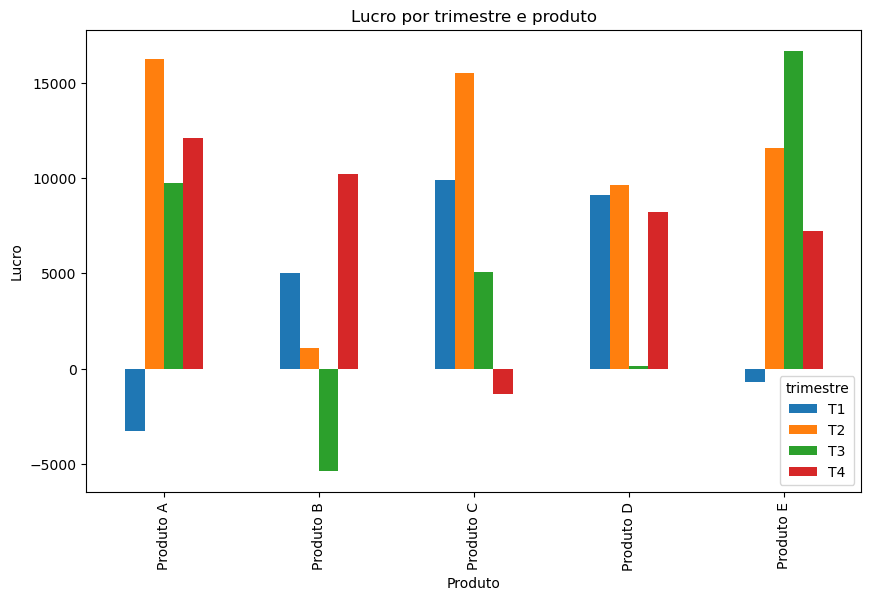

In [8]:
# gráfico de lucro por trimestre e produto
dados_long.pivot_table(
    index="produto_nome", columns="trimestre", values="lucro", aggfunc="mean"
).plot(kind="bar", figsize=(10, 6))

plt.title("Lucro por trimestre e produto")
plt.xlabel("Produto")
plt.ylabel("Lucro")

plt.show()

## E com os dados do vídeo sobre `melt`?

In [9]:
BASE = "./dados/dados_satisfacao.csv"

dados = pd.read_csv(BASE)

dados

,cliente_id,satisfacao_geral_01-2024,satisfacao_geral_02-2024,satisfacao_geral_03-2024,satisfacao_produto_01-2024,satisfacao_produto_02-2024,satisfacao_produto_03-2024,satisfacao_servico_01-2024,satisfacao_servico_02-2024,satisfacao_servico_03-2024,idade,genero
0,1,4,3,4,5,4,4,3,4,4,25,F
1,2,5,2,4,4,5,4,4,2,4,35,M
2,3,3,1,3,4,3,5,3,2,5,45,F
3,4,4,4,5,3,5,5,4,5,3,28,M
4,5,4,4,4,4,3,4,3,4,4,38,F
5,6,5,2,4,4,4,5,5,4,5,48,M
6,7,3,4,5,5,4,4,4,5,4,30,F
7,8,4,4,3,4,5,3,5,4,4,40,M
8,9,5,3,4,5,4,4,4,3,5,50,F
9,10,3,4,5,4,3,5,2,3,4,32,M


In [11]:
dados_long = pd.wide_to_long(
    dados,
    stubnames=["satisfacao_geral", "satisfacao_produto", "satisfacao_servico"],
    i="cliente_id",
    j="mes",
    sep="_",
    suffix="[0-9]{2}-[0-9]{4}",
).reset_index()

dados_long

,cliente_id,mes,idade,genero,satisfacao_geral,satisfacao_produto,satisfacao_servico
0,1,01-2024,25,F,4,5,3
1,2,01-2024,35,M,5,4,4
2,3,01-2024,45,F,3,4,3
3,4,01-2024,28,M,4,3,4
4,5,01-2024,38,F,4,4,3
5,6,01-2024,48,M,5,4,5
6,7,01-2024,30,F,3,5,4
7,8,01-2024,40,M,4,4,5
8,9,01-2024,50,F,5,5,4
9,10,01-2024,32,M,3,4,2


In [12]:
dados_long_melted = dados_long.melt(
    id_vars=["cliente_id", "mes", "idade", "genero"],
    value_vars=["satisfacao_geral", "satisfacao_produto", "satisfacao_servico"],
    var_name="categoria",
    value_name="nota",
)

dados_long_melted

,cliente_id,mes,idade,genero,categoria,nota
0,1,01-2024,25,F,satisfacao_geral,4
1,2,01-2024,35,M,satisfacao_geral,5
2,3,01-2024,45,F,satisfacao_geral,3
3,4,01-2024,28,M,satisfacao_geral,4
4,5,01-2024,38,F,satisfacao_geral,4
...,...,...,...,...,...,...
85,6,03-2024,48,M,satisfacao_servico,5
86,7,03-2024,30,F,satisfacao_servico,4
87,8,03-2024,40,M,satisfacao_servico,4
88,9,03-2024,50,F,satisfacao_servico,5


Observe que já foi feita a separação da coluna com data, mas ainda há três colunas para categorias de satisfação. Para juntá-las, será necessário o `melt` de qualquer forma:

In [13]:
dados_long_melted = dados_long.melt(
    id_vars=["cliente_id", "mes", "idade", "genero"],
    value_vars=["satisfacao_geral", "satisfacao_produto", "satisfacao_servico"],
    var_name="categoria",
    value_name="nota",
)

dados_long_melted

,cliente_id,mes,idade,genero,categoria,nota
0,1,01-2024,25,F,satisfacao_geral,4
1,2,01-2024,35,M,satisfacao_geral,5
2,3,01-2024,45,F,satisfacao_geral,3
3,4,01-2024,28,M,satisfacao_geral,4
4,5,01-2024,38,F,satisfacao_geral,4
...,...,...,...,...,...,...
85,6,03-2024,48,M,satisfacao_servico,5
86,7,03-2024,30,F,satisfacao_servico,4
87,8,03-2024,40,M,satisfacao_servico,4
88,9,03-2024,50,F,satisfacao_servico,5


A partir daqui, basta fazer os mesmos tratamentos mostrados no vídeo sobre `melt` (pegar apenas o mês da data, mudar tipos, etc).

In [14]:
dados_long_melted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   cliente_id  90 non-null     int64 
 1   mes         90 non-null     object
 2   idade       90 non-null     int64 
 3   genero      90 non-null     object
 4   categoria   90 non-null     object
 5   nota        90 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 4.3+ KB


In [15]:
dados_long_melted["mes"] = pd.to_datetime(dados_long_melted["mes"], format="%m-%Y")
dados_long_melted["mes"] = dados_long_melted["mes"].dt.month

dados_long_melted["genero"] = dados_long_melted["genero"].astype("category")
dados_long_melted["categoria"] = dados_long_melted["categoria"].astype("category")

dados_long_melted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   cliente_id  90 non-null     int64   
 1   mes         90 non-null     int32   
 2   idade       90 non-null     int64   
 3   genero      90 non-null     category
 4   categoria   90 non-null     category
 5   nota        90 non-null     int64   
dtypes: category(2), int32(1), int64(3)
memory usage: 3.0 KB


<Axes: xlabel='categoria', ylabel='nota'>

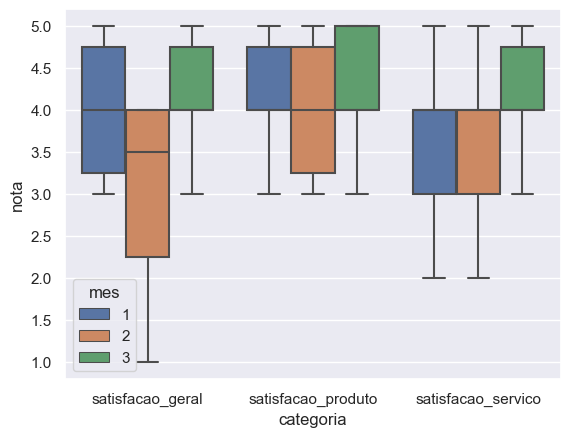

In [16]:
import seaborn as sns

sns.set_theme()

sns.boxplot(data=dados_long_melted, x="categoria", y="nota", hue="mes")